<a href="https://colab.research.google.com/github/andiandiandika3-prog/Mechine-Learning/blob/main/LigthGBM/Model%20training%20dan%20testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Library

In [75]:
if (!require(lightgbm)) install.packages("lightgbm")
if (!require(modeldata)) install.packages("modeldata")
if (!require(dplyr)) install.packages("dplyr")
if (!require(fastDummies)) install.packages("fastDummies")
if (!require(pROC)) install.packages("pROC")
if (!require(ggplot2)) install.packages("ggplot2")
if (!require(care)) install.packages("caret")


library(lightgbm)
library(modeldata)
library(dplyr)
library(fastDummies)
library(pROC)
library(ggplot2)
library(caret)

Loading required package: care

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘care’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘proxy’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘timeDate’, ‘e1071’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘recipes’, ‘reshape2’


Loading required package: lattice



# Muat data

In [41]:
df <- read.csv("https://drive.google.com/uc?export=download&id=1uKeYEEwRSddzg9-edUsRdIHot0O5om9D")
df <- na.omit(df)
cat("------------------------------------------------------------------------------\n")
cat("Struktur Data Awal\n")
cat("------------------------------------------------------------------------------\n")
str(df)

cat("------------------------------------------------------------------------------\n")
cat("Menyesuaikan Struktur data\n")
cat("------------------------------------------------------------------------------\n")
df <- df %>%
  mutate(across(c(SEX,EDUCATION,MARRIAGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6),as.factor))
str(df)

------------------------------------------------------------------------------
Struktur Data Awal
------------------------------------------------------------------------------
'data.frame':	30000 obs. of  25 variables:
 $ ID                        : int  1 2 3 4 5 6 7 8 9 10 ...
 $ LIMIT_BAL                 : num  20000 120000 90000 50000 50000 50000 500000 100000 140000 20000 ...
 $ SEX                       : int  2 2 2 2 1 1 1 2 2 1 ...
 $ EDUCATION                 : int  2 2 2 2 2 1 1 2 3 3 ...
 $ MARRIAGE                  : int  1 2 2 1 1 2 2 2 1 2 ...
 $ AGE                       : int  24 26 34 37 57 37 29 23 28 35 ...
 $ PAY_0                     : int  2 -1 0 0 -1 0 0 0 0 -2 ...
 $ PAY_2                     : int  2 2 0 0 0 0 0 -1 0 -2 ...
 $ PAY_3                     : int  -1 0 0 0 -1 0 0 -1 2 -2 ...
 $ PAY_4                     : int  -1 0 0 0 0 0 0 0 0 -2 ...
 $ PAY_5                     : int  -2 0 0 0 0 0 0 0 0 -1 ...
 $ PAY_6                     : int  -2 2 0 0 0 0 0 -

# Mempersiapkan data

In [42]:
y <- df$default.payment.next.month
x <- df %>% select(-c(ID,default.payment.next.month))

cat("------------------------------------------------------------------------------\n")
cat("Struktur Data prediktor\n")
cat("------------------------------------------------------------------------------\n")
str(x)

------------------------------------------------------------------------------
Struktur Data prediktor
------------------------------------------------------------------------------
'data.frame':	30000 obs. of  23 variables:
 $ LIMIT_BAL: num  20000 120000 90000 50000 50000 50000 500000 100000 140000 20000 ...
 $ SEX      : Factor w/ 2 levels "1","2": 2 2 2 2 1 1 1 2 2 1 ...
 $ EDUCATION: Factor w/ 7 levels "0","1","2","3",..: 3 3 3 3 3 2 2 3 4 4 ...
 $ MARRIAGE : Factor w/ 4 levels "0","1","2","3": 2 3 3 2 2 3 3 3 2 3 ...
 $ AGE      : int  24 26 34 37 57 37 29 23 28 35 ...
 $ PAY_0    : Factor w/ 11 levels "-2","-1","0",..: 5 2 3 3 2 3 3 3 3 1 ...
 $ PAY_2    : Factor w/ 11 levels "-2","-1","0",..: 5 5 3 3 3 3 3 2 3 1 ...
 $ PAY_3    : Factor w/ 11 levels "-2","-1","0",..: 2 3 3 3 2 3 3 2 5 1 ...
 $ PAY_4    : Factor w/ 11 levels "-2","-1","0",..: 2 3 3 3 3 3 3 3 3 1 ...
 $ PAY_5    : Factor w/ 10 levels "-2","-1","0",..: 1 3 3 3 3 3 3 3 3 2 ...
 $ PAY_6    : Factor w/ 10 levels "-2"

# Paramter dasar Dan Running Model LigthGBM

| Parameter                | Macam Fungsi (Opsi)                                           | Default (R / umum) | Keterangan                    |
| ------------------------ | ------------------------------------------------------------- | ------------------ | ----------------------------- |
| boosting                 | gbdt, rf, dart                                                | gbdt               | Tipe boosting                 |
| objective                | regression, binary, multiclass, multiclassova, poisson, huber | regression         | Fungsi tujuan (loss function) |
| metric                   | rmse, mae, binary_logloss, multi_logloss, auc                 | sesuai objective   | Metrik evaluasi               |
| learning_rate            | 0 – 1                                                         | 0.1                | Learning rate                 |
| num_leaves               | 1 – ∞ (umumnya 20–150)                                        | 31                 | Jumlah leaf maksimum          |
| max_depth                | -1 (tidak dibatasi), atau >0                                  | -1                 | Kedalaman maksimum tree       |
| min_data_in_leaf         | 0 – ∞                                                         | 20                 | Minimum data per leaf         |
| min_gain_to_split        | 0 – ∞                                                         | 0                  | Minimum gain untuk split      |
| feature_fraction         | 0 – 1                                                         | 1                  | Proporsi fitur (colsample)    |
| bagging_fraction         | 0 – 1                                                         | 1                  | Proporsi data (subsample)     |
| bagging_freq             | integer ≥ 0                                                   | 0                  | Frekuensi bagging             |
| lambda_l1                | 0 – ∞                                                         | 0                  | L1 regularization             |
| lambda_l2                | 0 – ∞                                                         | 0                  | L2 regularization             |
| scale_pos_weight         | 0 – ∞                                                         | 1                  | Handling imbalance            |
| nrounds / num_iterations | integer > 0                                                   | 100                | Jumlah iterasi boosting       |
| early_stopping_round     | integer > 0                                                   | NULL               | Early stopping                |


| Opsi          | Fungsi                                                                                                    |
| ------------- | --------------------------------------------------------------------------------------------------------- |
| gbdt          | Gradient Boosting Decision Tree, default LightGBM dan paling umum digunakan.                              |
| rf            | Random Forest mode, menggunakan bagging tanpa boosting penuh.                                             |
| dart          | Dropout tree seperti XGBoost DART, mengurangi overfitting dengan menjatuhkan sebagian tree saat training. |
| regression    | Untuk target kontinu (mirip reg:squarederror di XGBoost).                                                 |
| binary        | Klasifikasi biner (output probabilitas).                                                                  |
| multiclass    | Klasifikasi multikelas dengan softmax (butuh num_class).                                                  |
| multiclassova | One-vs-all multiclass classification.                                                                     |
| poisson       | Untuk count data (misalnya jumlah kejadian).                                                              |
| huber         | Robust regression terhadap outlier.                                                                       |


In [43]:
set.seed(123)

categorical_features <- c("SEX", "EDUCATION", "MARRIAGE", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6")

x_matrix <- as.matrix(x)

par_lgb <- list(
  objective = "binary",
  metric = "auc",
  learning_rate = 0.1,
  num_leaves = 31L,
  feature_fraction = 0.8,
  bagging_fraction = 0.8,
  bagging_freq = 1L,
  min_data_in_leaf = 20L)

dtrain <- lgb.Dataset(data = x_matrix, label = y, categorical_feature = categorical_features)
model <- lgb.train(
  params = par_lgb,
  data = dtrain,
  valids = list(train = dtrain),
  nrounds = 20,
  verbose = 1
)

[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negativ

## Fitur penting

------------------------------------------------------------------------------
Fitur penting
------------------------------------------------------------------------------
      Feature       Gain      Cover  Frequency
       <char>      <num>      <num>      <num>
 1:     PAY_0 0.32876457 0.11751606 0.03000000
 2:     PAY_2 0.29008882 0.08137721 0.02500000
 3: LIMIT_BAL 0.04856206 0.12192671 0.12666667
 4:  PAY_AMT2 0.04833275 0.08329586 0.07166667
 5: BILL_AMT1 0.03139983 0.07422616 0.08000000
 6:     PAY_4 0.02845082 0.03939770 0.01666667
 7:  PAY_AMT3 0.02217057 0.04907770 0.04333333
 8:  PAY_AMT1 0.02162883 0.06113923 0.05666667
 9:     PAY_3 0.02116391 0.05170898 0.02000000
10: BILL_AMT2 0.01938191 0.05409560 0.07333333
------------------------------------------------------------------------------
Plot Fitur penting
------------------------------------------------------------------------------


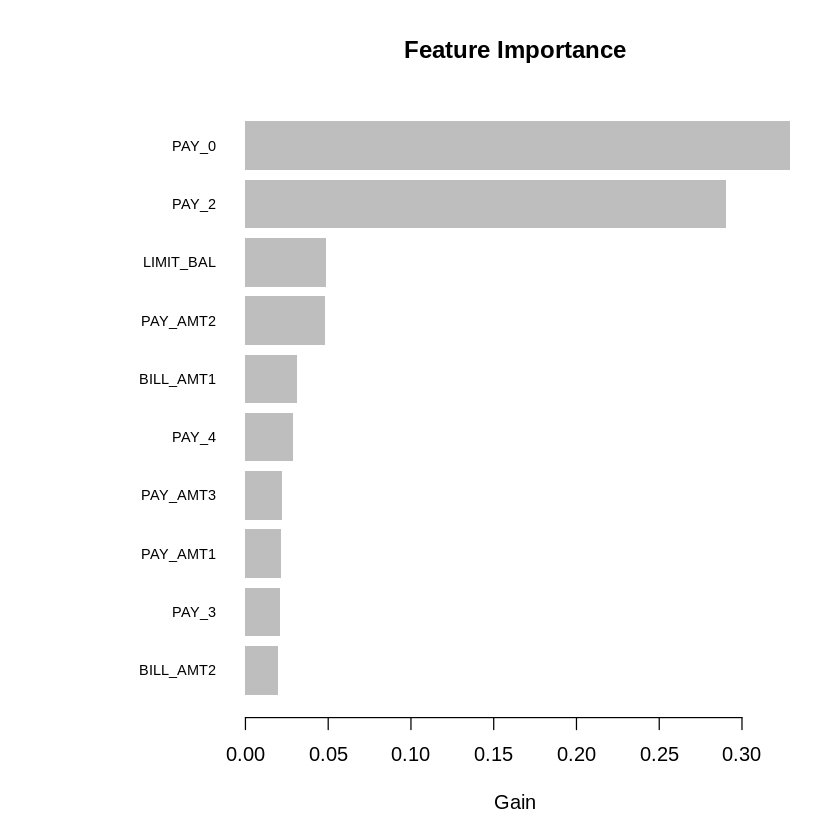

In [50]:
cat("------------------------------------------------------------------------------\n")
cat("Fitur penting\n")
cat("------------------------------------------------------------------------------\n")
imp <- lgb.importance(model, percentage = T)
print(head(imp,10))

cat("------------------------------------------------------------------------------\n")
cat("Plot Fitur penting\n")
cat("------------------------------------------------------------------------------\n")
lgb.plot.importance(imp, top_n = 10)

# Membagi menjadi data Training dan testing

In [58]:
set.seed(123)

train_index <- sample(nrow(df),0.8*nrow(df))

x_train <- x[train_index,]
y_train <- y[train_index]

x_test <- x[-train_index,]
y_test <- y[-train_index]

cat("----------------------------------------------------\n")
cat("Panjang Data train dan test\n")
cat("----------------------------------------------------\n")
cat("Panjang data ", nrow(x), "\n")
cat("Panjang train ", nrow(x_train), "\n")
cat("Panjang test ", nrow(x_test), "\n")

----------------------------------------------------
Panjang Data train dan test
----------------------------------------------------
Panjang data  30000 
Panjang train  24000 
Panjang test  6000 


## Model dengan data training dan testing

In [61]:
dtrain <- lgb.Dataset(data = as.matrix(x_train), label = y_train, categorical_feature = categorical_features)
dtest <- lgb.Dataset(data = as.matrix(x_test), label = y_test, categorical_feature = categorical_features)

model_tr <- lgb.train(
  params = par_lgb,
  data = dtrain,
  valids = list(train = dtrain),
  nrounds = 20,
  verbose = 1
)

[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negativ

## Membuat prediksi  




In [119]:
hasil <- ifelse(predict(model_tr,newdata = as.matrix(x_test))>= 0.5,1,0)

table(
  hasil = hasil,
  actual = y_test
)

auc_val <- auc(y_test, hasil)
cat(sprintf("Test AUC = %.4f\n", as.numeric(auc_val)))

mean(predict(model_tr, newdata = as.matrix(x_test)))

     actual
hasil    0    1
    0 4512  912
    1  198  378

Setting levels: control = 0, case = 1

Setting direction: controls < cases



Test AUC = 0.6255


[1] 0.2225812